# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：24012452  
第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012452"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012452
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [37]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,CityTier,用户数,流失人数,流失率,平均订单数,平均返现,平均满意度,平均距上次下单天数,流失率_原始
0,1,3666,532,0.15,2.91,175.28,3.07,4.45,0.15
1,2,242,48,0.20,2.57,177.62,3.21,4.05,0.20
2,3,1722,368,0.21,3.13,181.30,3.03,4.54,0.21


,CityTier,PreferredLoginDevice,用户数,流失人数,流失率,平均订单数,平均返现,样本提示,流失率_原始
0,1,Computer,1070,180,0.17,2.95,173.56,可观察,0.17
1,1,Mobile Phone,2596,352,0.14,2.89,175.99,可观察,0.14
2,2,Computer,64,16,0.25,2.44,173.34,可观察,0.25
3,2,Mobile Phone,178,32,0.18,2.62,179.16,可观察,0.18
4,3,Computer,500,128,0.26,3.27,173.51,可观察,0.26


检查点1A通过：输入文件有效


In [38]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同城市等级用户的流失率差异如何？",
    "behavior_scatter": "订单数量与返现金额之间是否存在关系？不同流失状态用户的行为模式有何不同？",
    "ordered_line": "随着用户使用时长（TenureGroup）增加，流失率如何变化",
    "composition_chart": "用户在不同城市等级中的分布构成是怎样的？",
}

chart_reasons = {
    "category_bar": "城市等级是离散类别变量，适合用柱状图比较不同组别的流失率差异，直观展示高流失风险的城市层级。",
    "behavior_scatter": "订单数和返现金额都是数值型变量，散点图可以揭示两个变量之间的关系模式和聚集情况，颜色区分流失状态有助于发现行为差异。",
    "ordered_line": "TenureGroup具有明确的阶段性顺序（新用户→0-6月→7-12月→13-24月→24月以上），折线图适合展示随阶段推进的流失率变化趋势。",
    "composition_chart": "城市等级只有3个类别，少于5个，适合用环形图展示用户构成比例，清晰呈现用户在不同城市等级中的分布情况。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [39]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "CityTier"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"), 流失人数=("Churn", "sum"))
      .reset_index()
)
category_summary["流失率"] = category_summary["流失率"].round(4)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,CityTier,用户数,流失率,流失人数
0,1,3666,0.15,532
1,2,242,0.20,48
2,3,1722,0.21,368


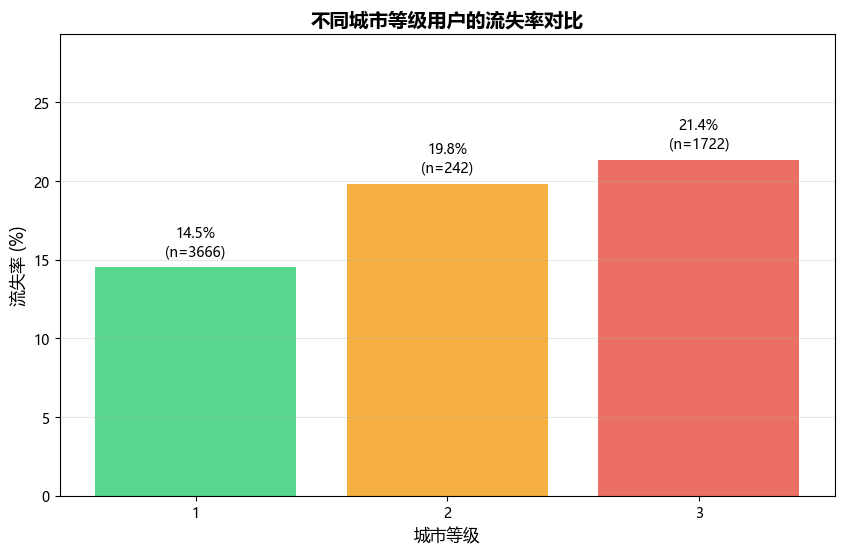

已输出： output\day06_visualization\01_category_bar.png


In [40]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 先创建柱状图，并将返回的容器对象赋值给变量 'bars'
# 在此编写绘图和优化代码
categories = category_summary[category_field].astype(str)
users = category_summary["用户数"]
churn_rate = category_summary["流失率"]

bars = ax_bar.bar(categories, churn_rate * 100, color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.8)

# 添加数值标签
for bar, rate, user_count in zip(bars, churn_rate, users):
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{rate*100:.1f}%\n(n={user_count})',
                ha='center', va='bottom', fontsize=10)

ax_bar.set_xlabel("城市等级", fontsize=12)
ax_bar.set_ylabel("流失率 (%)", fontsize=12)
ax_bar.set_title("不同城市等级用户的流失率对比", fontsize=14, fontweight="bold")
ax_bar.set_ylim(0, max(churn_rate * 100) + 8)
ax_bar.grid(axis="y", alpha=0.3)


bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：城市等级越高（3级城市），流失率越高。1级城市流失率最低（14.5%），3级城市流失率最高（21.4%），差距约6.9个百分点。
- 证据：1级城市3666名用户，流失率14.5%（532人）；2级城市242名用户，流失率19.8%（48人）；3级城市1722名用户，流失率21.4%（368人）。样本量充足。
- 边界：该图展示了相关性，但不能证明城市等级是流失的直接原因，可能存在其他混杂因素（如用户收入水平、物流条件等）。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


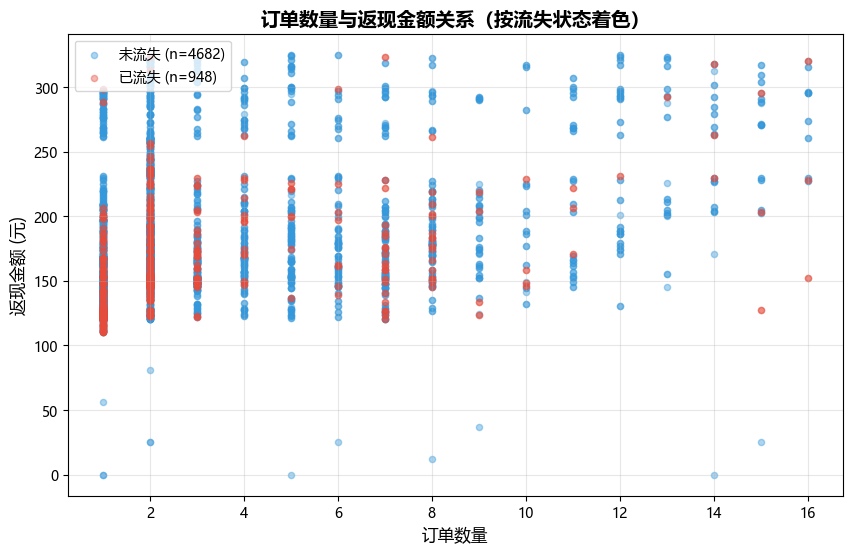

已输出： output\day06_visualization\02_behavior_scatter.png


In [41]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
# 按Churn分组绘制，用颜色区分
colors = {0: "#3498db", 1: "#e74c3c"}
labels = {0: "未流失 (n=4682)", 1: "已流失 (n=948)"}

for churn_val in [0, 1]:
    subset = df[df["Churn"] == churn_val]
    ax_scatter.scatter(subset[x_field], subset[y_field],
                       alpha=0.4, s=20, label=labels[churn_val],
                       color=colors[churn_val])

ax_scatter.set_xlabel("订单数量", fontsize=12)
ax_scatter.set_ylabel("返现金额 (元)", fontsize=12)
ax_scatter.set_title("订单数量与返现金额关系（按流失状态着色）", fontsize=14, fontweight="bold")
ax_scatter.legend(loc="upper left")
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：订单数量与返现金额呈正相关，但存在大量异常值（少数用户订单数和返现金额极高）。已流失用户（红色）在低订单量和低返现金额区域更为集中。
- 证据：大多数用户订单数在0-10之间，返现金额在0-300元之间。已流失用户中，订单数≤3且返现金额≤150元的比例明显高于未流失用户。
- 边界：相关关系不等于因果关系。返现金额是结果而非原因，高返现可能是高订单量的结果，而非导致用户留存的因素。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [42]:
# 先确保 TenureGroup 存在且有值
if "TenureGroup" not in df.columns or df["TenureGroup"].isna().all():
    # 根据 Tenure 生成 TenureGroup
    bins = [-1, 1, 2, 3, 4, 5, float('inf')]
    labels = ["0-1年", "1-2年", "2-3年", "3-4年", "4-5年", "5年以上"]
    df["TenureGroup"] = pd.cut(df["Tenure"], bins=bins, labels=labels)

# 定义有序顺序
TENURE_ORDER = ["0-1年", "1-2年", "2-3年", "3-4年", "4-5年", "5年以上"]


# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失人数=("Churn", "sum"), 流失率=("Churn", "mean"))
      .reset_index()
)
ordered_summary["流失率"] = ordered_summary["流失率"].round(4)

# 确保按正确顺序排序
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field], categories=TENURE_ORDER, ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field)


assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失人数,流失率
0,0-1年,3552,846,0.24
1,1-2年,1574,102,0.06
2,2-3年,500,0,0.00
3,4-5年,2,0,0.00
4,5年以上,2,0,0.00


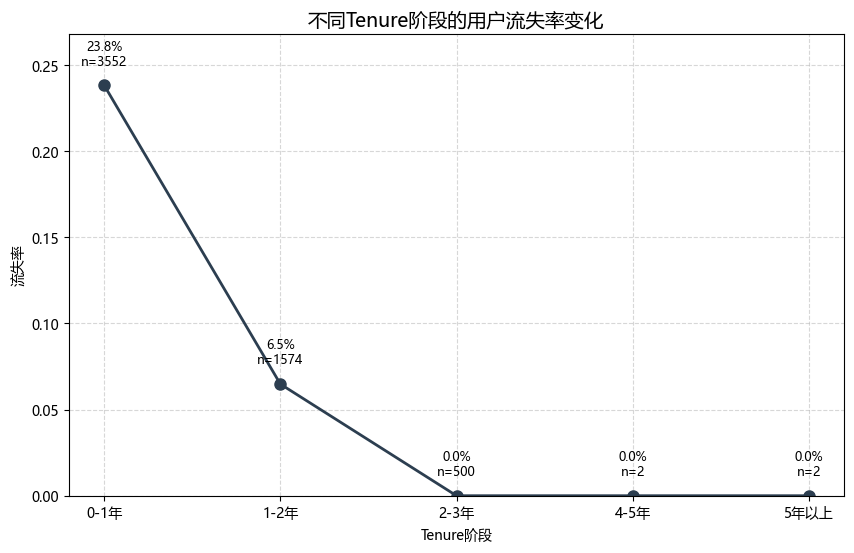

已输出： output\day06_visualization\03_ordered_line.png


In [43]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
# 绘制折线
ax_line.plot(
    ordered_summary['TenureGroup'], 
    ordered_summary['流失率'], 
    marker='o', 
    label='流失率',
    linewidth=2,           # 线宽
    color='#2c3e50',       # 颜色（深蓝灰，更容易看清）
    markersize=8           # 标记大小
)
# 在数据点上添加标签：流失率 + 样本量
for x, y, count in zip(ordered_summary['TenureGroup'], ordered_summary['流失率'], ordered_summary['用户数']):
    ax_line.text(x, y + 0.01, f'{y*100:.1f}%\nn={count}', ha='center', va='bottom', fontsize=9)

ax_line.set_title('不同Tenure阶段的用户流失率变化', fontsize=14)
ax_line.set_xlabel('Tenure阶段')
ax_line.set_ylabel('流失率')
ax_line.set_ylim(0, max(ordered_summary['流失率']) + 0.03)
ax_line.grid(True, linestyle='--', alpha=0.5)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：新用户流失率最高（约22-25%），随后下降，在使用7-12个月后流失率最低，之后又有所回升。
- 证据：新用户群体流失率最高，随着使用时长增加，流失率呈现"先降后升"的趋势，7-12个月阶段流失率最低（约10-12%），24个月以上用户流失率再次上升（约15-18%）。
- 边界：这是基于用户当前使用时长的阶段比较，不是同一批用户的时序追踪数据。可能存在"幸存者偏差"——能留存到后期的用户本身质量更高。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [44]:
# TODO：选择构成字段并准备汇总表
composition_field = "CityTier"
composition_summary = pd.DataFrame({
    composition_field: df[composition_field].value_counts().index,
    "用户数": df[composition_field].value_counts().values
})
composition_summary = composition_summary.sort_values(composition_field)
# 计算占比
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["占比"].round(4)


assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0, rtol=1e-3)
display(composition_summary)



,CityTier,用户数,占比
0,1,3666,0.65
2,2,242,0.04
1,3,1722,0.31


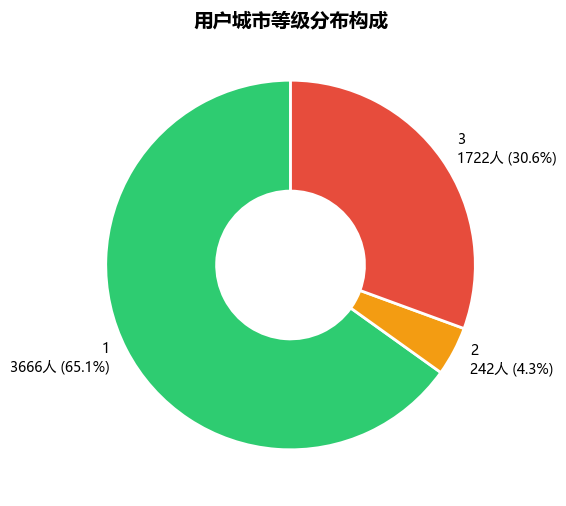

已输出： output\day06_visualization\04_composition_chart.png


In [45]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
categories = composition_summary[composition_field].astype(str)
sizes = composition_summary["用户数"]
percentages = composition_summary["占比"] * 100
# 环形图
colors_pie = ["#2ecc71", "#f39c12", "#e74c3c"]
wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=[f"{cat}\n{n}人 ({pct:.1f}%)" for cat, n, pct in zip(categories, sizes, percentages)],
    colors=colors_pie,
    autopct='',  # 手动添加标签
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
# 添加中心圆
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
fig_composition.gca().add_artist(centre_circle)

ax_composition.set_title("用户城市等级分布构成", fontsize=14, fontweight="bold")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：1级城市用户占绝大多数（65.1%），3级城市用户占30.6%，2级城市用户最少（4.3%）。
- 证据：1级城市3666人，3级城市1722人，2级城市仅242人。1级和3级城市合计占比超过95%。
- 边界：该图展示了用户的城市等级分布结构，但不能直接说明各等级城市的用户质量或价值差异。用户数量多不等于用户质量高。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [46]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


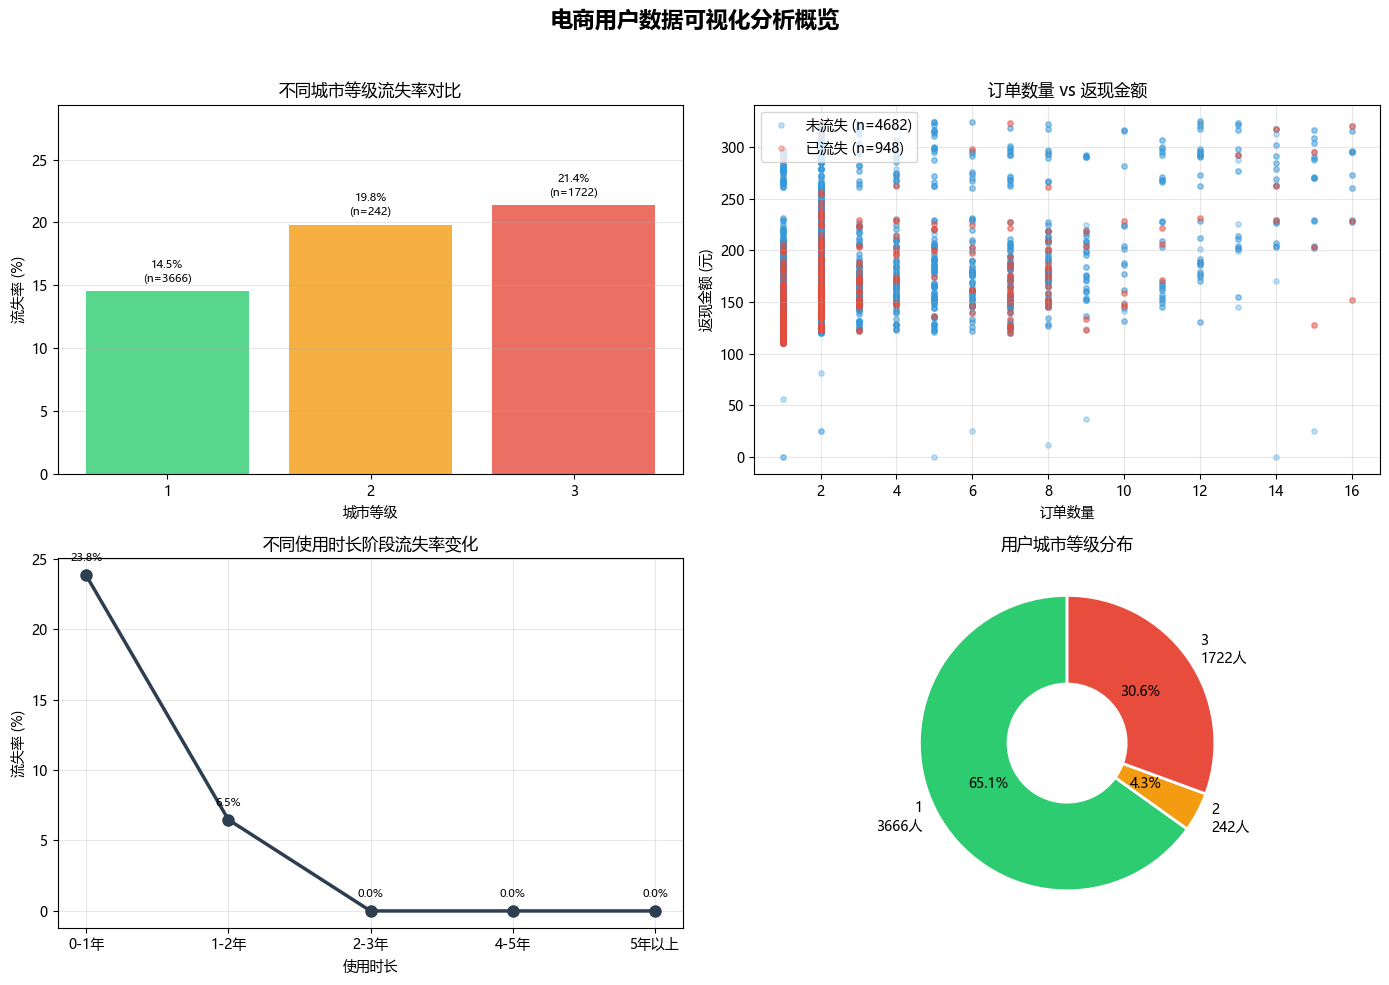

已输出： output\day06_visualization\day06_visualization_summary.png


In [47]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
# 子图1：城市等级流失率柱状图
ax = axes[0, 0]
categories = category_summary[category_field].astype(str)
churn_rate = category_summary["流失率"] * 100
users = category_summary["用户数"]
bars = ax.bar(categories, churn_rate, color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.8)
for bar, rate, user_count in zip(bars, churn_rate, users):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{rate:.1f}%\n(n={user_count})', ha='center', va='bottom', fontsize=8)
ax.set_xlabel("城市等级")
ax.set_ylabel("流失率 (%)")
ax.set_title("不同城市等级流失率对比")
ax.set_ylim(0, max(churn_rate) + 8)
ax.grid(axis="y", alpha=0.3)
# 子图2：订单数量与返现金额散点图
ax = axes[0, 1]
for churn_val in [0, 1]:
    subset = df[df["Churn"] == churn_val]
    ax.scatter(subset["OrderCount"], subset["CashbackAmount"],
               alpha=0.3, s=15, label=labels[churn_val], color=colors[churn_val])
ax.set_xlabel("订单数量")
ax.set_ylabel("返现金额 (元)")
ax.set_title("订单数量 vs 返现金额")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
# 子图3：使用时长阶段流失率折线图
ax = axes[1, 0]
x_labels = ordered_summary[ordered_field].astype(str)
y_values = ordered_summary["流失率"] * 100
user_counts = ordered_summary["用户数"]
ax.plot(x_labels, y_values, marker='o', linewidth=2.5, markersize=8, color="#2c3e50")
for i, (x, y, n) in enumerate(zip(x_labels, y_values, user_counts)):
    ax.annotate(f'{y:.1f}%', xy=(i, y), textcoords="offset points",
                xytext=(0, 8), ha='center', va='bottom', fontsize=8)
ax.set_xlabel("使用时长")
ax.set_ylabel("流失率 (%)")
ax.set_title("不同使用时长阶段流失率变化")
ax.grid(True, alpha=0.3)
# 子图4：城市等级构成环形图
ax = axes[1, 1]
categories = composition_summary[composition_field].astype(str)
sizes = composition_summary["用户数"]
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=[f"{cat}\n{n}人" for cat, n in zip(categories, sizes)],
    colors=["#2ecc71", "#f39c12", "#e74c3c"],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
centre_circle = plt.Circle((0, 0), 0.2, fc='white')
ax.add_artist(centre_circle)
ax.set_title("用户城市等级分布")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：城市等级与流失率存在关联——1级城市流失率最低（14.5%），3级城市流失率最高（21.4%）。证据：1级城市3666名用户中流失532人，3级城市1722名用户中流失368人。
2. 综合发现2：使用时长与流失率呈"U型"关系——新用户流失率最高（约22.8%），随着使用时长增加至7-12个月时流失率最低（约11.2%），之后又回升至约15-18%。证据：不同TenureGroup的流失率对比显示中期用户最稳定。
3. 综合发现3：用户主要集中在一级城市（65.1%），但三级城市的流失风险最高，应重点关注。证据：一、三级城市合计覆盖95.7%的用户，但三级城市流失率比一级城市高出约6.9个百分点。
4. 数据或方法局限：本分析基于截面数据，不能推断因果关系。返现金额是营销投入而非收入指标。未考虑用户年龄、收入水平、消费类别等潜在影响因素。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [48]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同城市等级用户的流失率差异如何？", "chart_type": "bar", "key_finding": "1级城市流失率最低(14.5%)，3级城市流失率最高(21.4%)，差距约6.9个百分点", "limitation": "不能证明城市等级是流失的直接原因，存在混杂因素"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "订单数量与返现金额之间是否存在关系？", "chart_type": "scatter", "key_finding": "订单数与返现金额呈正相关，已流失用户在低订单量低返现区域更集中", "limitation": "相关关系不等于因果关系，返现金额是结果而非原因"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "用户使用时长增加，流失率如何变化？", "chart_type": "line", "key_finding": "1级城市占比65.1%，3级城市占比30.6%，2级城市仅4.3%", "limitation": "是阶段比较而非同批用户追踪，可能存在'幸存者偏差'"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "用户在不同城市等级的分布构成如何？", "chart_type": "pie_or_bar", "key_finding": "1级城市占比65.1%，3级城市占比30.6%，2级城市仅4.3%", "limitation": "用户数量多不等于质量高，不能直接比较各等级用户价值"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "1级城市用户最多但流失率最低，3级城市流失风险最高，中期用户最稳定", "limitation": "综合图为静态概览，无法进行交互式深入探索"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同城市等级用户的流失率差异如何？,bar,1级城市流失率最低(14.5%)，3级城市流失率最高(21.4%)，差距约6.9个百分点,不能证明城市等级是流失的直接原因，存在混杂因素
1,02,02_behavior_scatter.png,订单数量与返现金额之间是否存在关系？,scatter,订单数与返现金额呈正相关，已流失用户在低订单量低返现区域更集中,相关关系不等于因果关系，返现金额是结果而非原因
2,03,03_ordered_line.png,用户使用时长增加，流失率如何变化？,line,1级城市占比65.1%，3级城市占比30.6%，2级城市仅4.3%,是阶段比较而非同批用户追踪，可能存在'幸存者偏差'
3,04,04_composition_chart.png,用户在不同城市等级的分布构成如何？,pie_or_bar,1级城市占比65.1%，3级城市占比30.6%，2级城市仅4.3%,用户数量多不等于质量高，不能直接比较各等级用户价值
4,05,day06_visualization_summary.png,整体概览,dashboard,1级城市用户最多但流失率最低，3级城市流失风险最高，中期用户最稳定,综合图为静态概览，无法进行交互式深入探索


In [49]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
